# Drift Simulation

Assuming we only train on 2002 to 2017, how many timesteps will it take for each of the models to drift from an acceptable range?

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("..")
from HelpingFunctions import ERCOTProcessor
from HelpingFunctions import WeatherProcessing
from HelpingFunctions import FeatureEngineering
from HelpingFunctions import ForecastingHelpers

import onnxruntime as ort
ort.set_default_logger_severity(4)
from mapie.regression import MapieRegressor
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 125

In [2]:
# Does not like processing between 2002-2024 in one go, split to allow for optimization
ercot_df_pt1 = ERCOTProcessor.fileprocessing(2002,2016)
ercot_df_pt2 = ERCOTProcessor.fileprocessing(2016,2024)
ercot_df = pd.concat([ercot_df_pt1, ercot_df_pt2])

In [3]:
# Process weather data
filename = 'ElectricityDemandAustinTX/LoadForecastingAttacks/Weather/weather_20022024.csv'
weather_df = pd.read_csv(filename).drop('Unnamed: 0', axis=1)
weather_df.columns = ['time', 'temp', 'humd', 'wnsp', 'cond']
weather_df.loc[:,'time'] = weather_df['time'].apply(lambda x: pd.to_datetime(x))
weather_df = weather_df.set_index('time')
weather_df.head()

,temp,humd,wnsp,cond
time,,,,
2002-01-01 00:00:00,36.0,0.64,7.0,0.0
2002-01-01 01:00:00,36.0,0.57,8.0,0.0
2002-01-01 02:00:00,36.0,0.57,8.0,0.0
2002-01-01 03:00:00,36.0,0.57,6.0,0.0
2002-01-01 04:00:00,35.0,0.61,8.0,0.0


In [4]:
# Concat weather and ERCOT data and deduplicate any values
full_df = FeatureEngineering.feature_engineering(weather_df, ercot_df)
full_df = full_df.drop_duplicates(subset=None, keep="last", inplace=False)
full_df = full_df[~full_df.index.duplicated()]

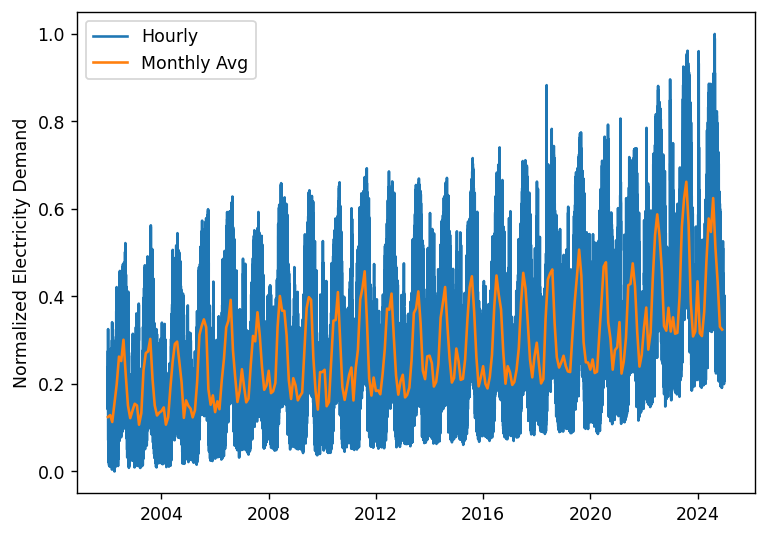

In [5]:
# Plot a monthly rolling average versus the true hourly value
monthly_norm = full_df['load'].resample('MS').mean().bfill()
plt.plot(full_df['load'], label='Hourly')
plt.plot(monthly_norm, label='Monthly Avg')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [6]:
# Trained on 2002 to 2014, validated on 2015-2016, tested on 2017-2024
train, validate, test = FeatureEngineering.train_test_split(monthly_norm, 2014, 2015, 2016, 2017)

## SARIMA

In [7]:
# Grid search for best fittimg model for training and valiadation dataset
from HelpingFunctions import sarima_modeling

search = sarima_modeling.grid_search(train, validate)

time
2002-01-01    0.124471
2002-02-01    0.128800
2002-03-01    0.113102
2002-04-01    0.157289
2002-05-01    0.199732
Freq: MS, Name: load, dtype: float64
    p  d  q  P  D  Q       mae
58  1  1  1  0  1  0  0.016718


In [8]:
search.values[0]

array([1, 1, 1, 0, 1, 0, 0.016717840777864926], dtype=object)

In [9]:
p,d,q,P,D,Q,mae = 1,1,1,0,1,0,0.0884

In [10]:
import joblib 

# Predict forecasted values 
model_sarima, sarima_forec, sarima_pred, sarima_ci = sarima_modeling.sarima(train, validate, 1, 1, 1, 0, 1, 1)
print('MAE:', ForecastingHelpers.compute_mae(validate, sarima_pred))
# Save the model
filename = 'ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/sarima.joblib'
joblib.dump(model_sarima, filename)

MAE: 0.023728585451924144


['ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/sarima.joblib']

Data up to 2016 (training + validation)

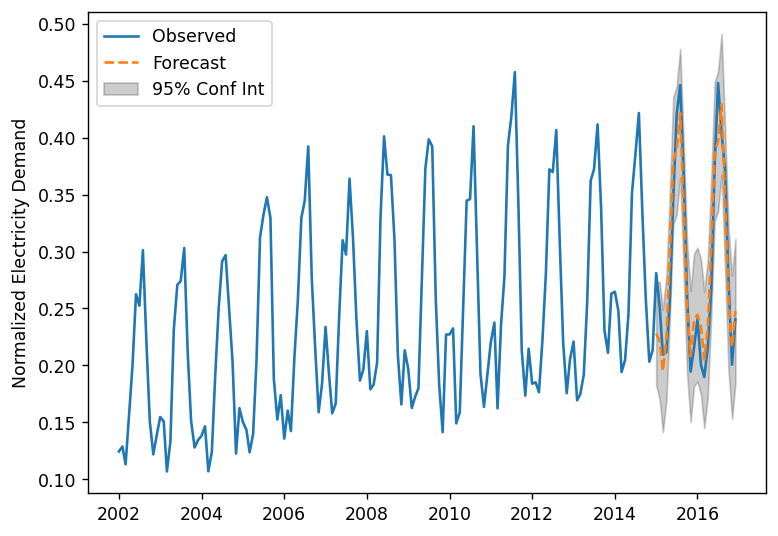

In [11]:
# plotting training and validation
plt.plot(monthly_norm[:'2016'], label='Observed')
plt.plot(sarima_pred, label='Forecast', ls='--')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                 color='k', alpha=0.2, label='95% Conf Int')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

Data 2017 and beyond

## Simulate KL divergence smoothing in "green zone"

In [12]:
# Calculate for 2017 to 2019
# Predict forecasted values for testing
drift_sarima, drift_forec, drift_pred, drift_ci = sarima_modeling.sarima(pd.concat([train, validate]), test[:'2019'], 1, 1, 1, 0, 1, 1)
print('MAE:', ForecastingHelpers.compute_mae(test, drift_pred))

MAE: 0.0197413380270801


In [13]:
diverge_orig = ForecastingHelpers.calculateKLDivergence(monthly_norm['2017':'2019'],drift_pred)

In [14]:
high_drift, med_drift, diverge = ForecastingHelpers.predictKL(diverge_orig)

In [15]:
high_drift

Timestamp('2024-09-01 00:00:00')

In [16]:
med_drift

Timestamp('2020-11-01 00:00:00')

In [17]:
drift_sarima, drift_forec, drift_pred, drift_ci = sarima_modeling.sarima(pd.concat([train, validate]), test, 1, 1, 1, 0, 1, 1)
print('MAE:', ForecastingHelpers.compute_mae(test, drift_pred))
full_diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm['2017':],drift_pred)

MAE: 0.04606286473177642


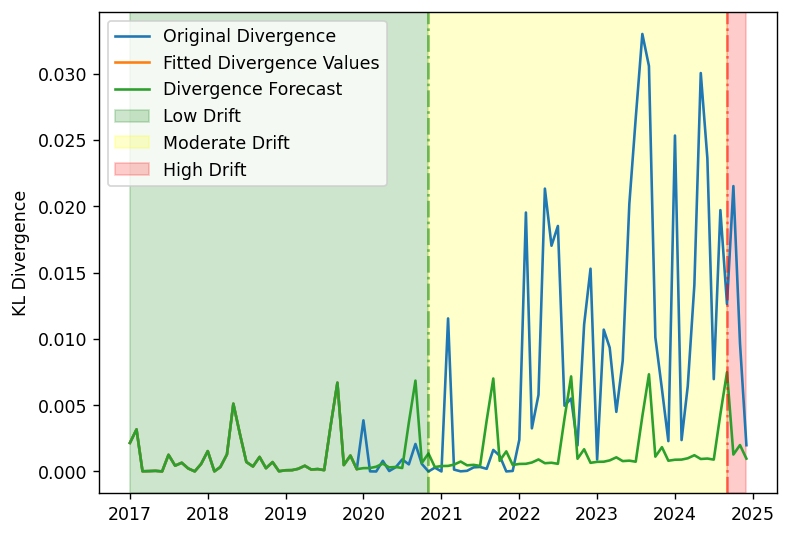

In [18]:
plt.plot(full_diverge, label='Original Divergence')
plt.plot(diverge_orig, label='Fitted Divergence Values')
plt.plot(diverge, label='Divergence Forecast')
plt.ylabel('KL Divergence')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(drift_pred.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,drift_pred.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.legend()
plt.show()

## Simulate KL divergence smoothing in "yellow zone"

In [19]:
# Calculate for 2017 to 2019
# Predict forecasted values for testing
drift_sarima, drift_forec, drift_pred, drift_ci = sarima_modeling.sarima(pd.concat([train, validate]), test[:'2021'], 1, 1, 1, 0, 1, 1)
print('MAE:', ForecastingHelpers.compute_mae(test, drift_pred))

MAE: 0.018875163222332847


In [20]:
diverge_orig = ForecastingHelpers.calculateKLDivergence(monthly_norm['2017':'2021'],drift_pred)

In [21]:
high_drift, med_drift, diverge = ForecastingHelpers.predictKL(diverge_orig)

In [22]:
med_drift

Timestamp('2021-02-01 00:00:00')

In [23]:
high_drift

Timestamp('2026-02-01 00:00:00')

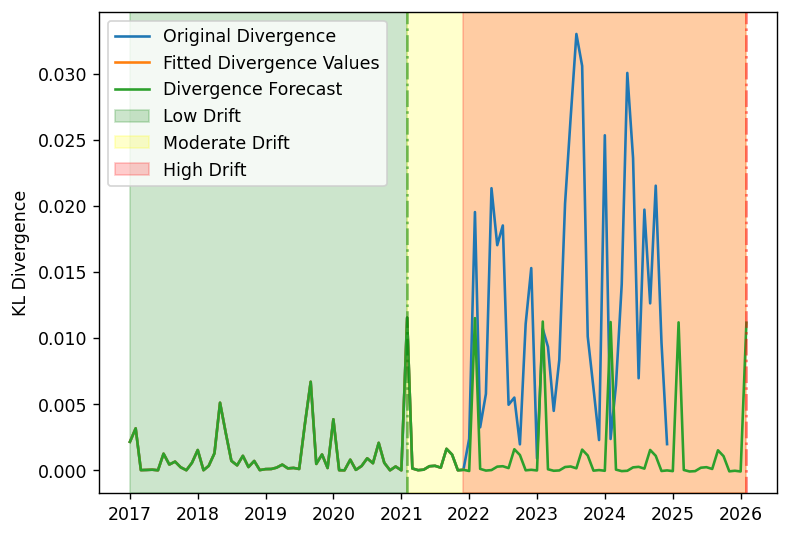

In [24]:
plt.plot(full_diverge, label='Original Divergence')
plt.plot(diverge_orig, label='Fitted Divergence Values')
plt.plot(diverge, label='Divergence Forecast')
plt.ylabel('KL Divergence')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(drift_pred.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,drift_pred.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.legend()
plt.show()

## Simulate KL divergence smoothing in "red zone"

In [30]:
# Calculate for 2017 to 2021
# Predict forecasted values for testing
drift_sarima, drift_forec, drift_pred, drift_ci = sarima_modeling.sarima(pd.concat([train, validate]), test, 1, 1, 1, 0, 1, 1)
print('MAE:', ForecastingHelpers.compute_mae(test, drift_pred))
diverge_orig = ForecastingHelpers.calculateKLDivergence(monthly_norm['2017':],drift_pred)
high_drift, med_drift, diverge = ForecastingHelpers.predictKL(diverge_orig)

MAE: 0.04606286473177642


In [31]:
med_drift

Timestamp('2021-02-01 00:00:00')

In [32]:
high_drift

Timestamp('2022-06-01 00:00:00')

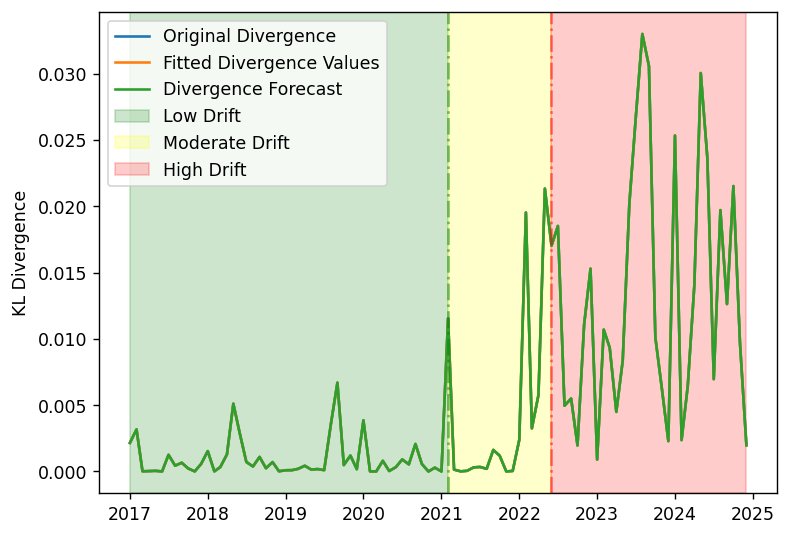

In [33]:
plt.plot(full_diverge, label='Original Divergence')
plt.plot(diverge_orig, label='Fitted Divergence Values')
plt.plot(diverge, label='Divergence Forecast')
plt.ylabel('KL Divergence')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(drift_pred.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,drift_pred.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.legend()
plt.show()